In [50]:
import pandas as pd

In [51]:
# Load data
df = pd.read_csv('../dataset/track_data_final.csv')

# Show first 5 rows
df.head(5)

,track_id,track_name,track_number,track_popularity,track_duration_ms,explicit,artist_name,artist_popularity,artist_followers,artist_genres,album_id,album_name,album_release_date,album_total_tracks,album_type
0,6pymOcrCnMuCWdgGVTvUgP,3,57,61,213173,False,Britney Spears,80.0,17755451.0,['pop'],325wcm5wMnlfjmKZ8PXIIn,The Singles Collection,2009-11-09,58,compilation
1,2lWc1iJlz2NVcStV5fbtPG,Clouds,1,67,158760,False,BUNT.,69.0,293734.0,['stutter house'],2ArRQNLxf9t0O0gvmG5Vsj,Clouds,2023-01-13,1,single
2,1msEuwSBneBKpVCZQcFTsU,Forever & Always (Taylor’s Version),11,63,225328,False,Taylor Swift,100.0,145396321.0,[],4hDok0OAJd57SGIT8xuWJH,Fearless (Taylor's Version),2021-04-09,26,album
3,7bcy34fBT2ap1L4bfPsl9q,I Didn't Change My Number,2,72,158463,True,Billie Eilish,90.0,118692183.0,[],0JGOiO34nwfUdDrD612dOp,Happier Than Ever,2021-07-30,16,album
4,0GLfodYacy3BJE7AI3A8en,Man Down,7,57,267013,False,Rihanna,90.0,68997177.0,[],5QG3tjE5L9F6O2vCAPph38,Loud,2010-01-01,13,album


### Data Dictionary

| Column | Meaning | Example |
|---|---|---|
| `track_id` | Unique ID for the track | `6pymOcrCnMuCWdgGVTvUgP` |
| `track_name` | Name of the track | `3` |
| `track_number` | Track number in the album | `57` |
| `track_popularity` | Popularity score (0-100) | `61` |
| `track_duration_ms` | Duration in milliseconds | `213173` |
| `explicit` | Explicit content flag | `False` |
| `artist_name` | Name of the artist | `Britney Spears` |
| `artist_popularity` | Artist popularity score | `80.0` |
| `artist_followers` | Number of artist followers | `17755451.0` |
| `artist_genres` | Genres associated with artist | `['pop']` |
| `album_id` | Unique ID for the album | `325wcm5wMnlfjmKZ8PXIIn` |
| `album_name` | Name of the album | `The Singles Collection` |
| `album_release_date` | Release date of the album | `2009-11-09` |
| `album_total_tracks` | Total tracks in the album | `58` |
| `album_type` | Type of album (album, single, etc.) | `compilation` |

## Phân tích: Explicit Content có ảnh hưởng đến Popularity không?

In [52]:
# Import libraries và chuẩn bị dữ liệu
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Kiểm tra phân bố explicit
print("Phân bố Explicit Content:")
print(df['explicit'].value_counts())
print(f"\nTỷ lệ Explicit: {df['explicit'].sum() / len(df) * 100:.2f}%")
print(f"Tỷ lệ Non-Explicit: {(~df['explicit']).sum() / len(df) * 100:.2f}%")

# Thống kê cơ bản
print("\n\nThống kê Track Popularity:")
print(df.groupby('explicit')['track_popularity'].describe())

print("\n\nThống kê Artist Popularity:")
print(df.groupby('explicit')['artist_popularity'].describe())

Phân bố Explicit Content:
explicit
False    6586
True     2192
Name: count, dtype: int64

Tỷ lệ Explicit: 24.97%
Tỷ lệ Non-Explicit: 75.03%


Thống kê Track Popularity:
           count       mean        std  min   25%   50%   75%    max
explicit                                                            
False     6586.0  50.475858  24.276791  0.0  36.0  55.0  70.0  100.0
True      2192.0  57.511861  22.658959  0.0  50.0  64.0  73.0   94.0


Thống kê Artist Popularity:
           count       mean        std  min   25%   50%   75%    max
explicit                                                            
False     6583.0  68.014735  19.683579  0.0  57.0  72.0  82.0  100.0
True      2191.0  75.784573  17.849783  0.0  70.0  81.0  88.0  100.0


C:\Users\LIANLI\AppData\Local\Temp\ipykernel_26968\1384262020.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  popularity_explicit = df.groupby(['popularity_range', 'explicit']).size().unstack(fill_value=0)


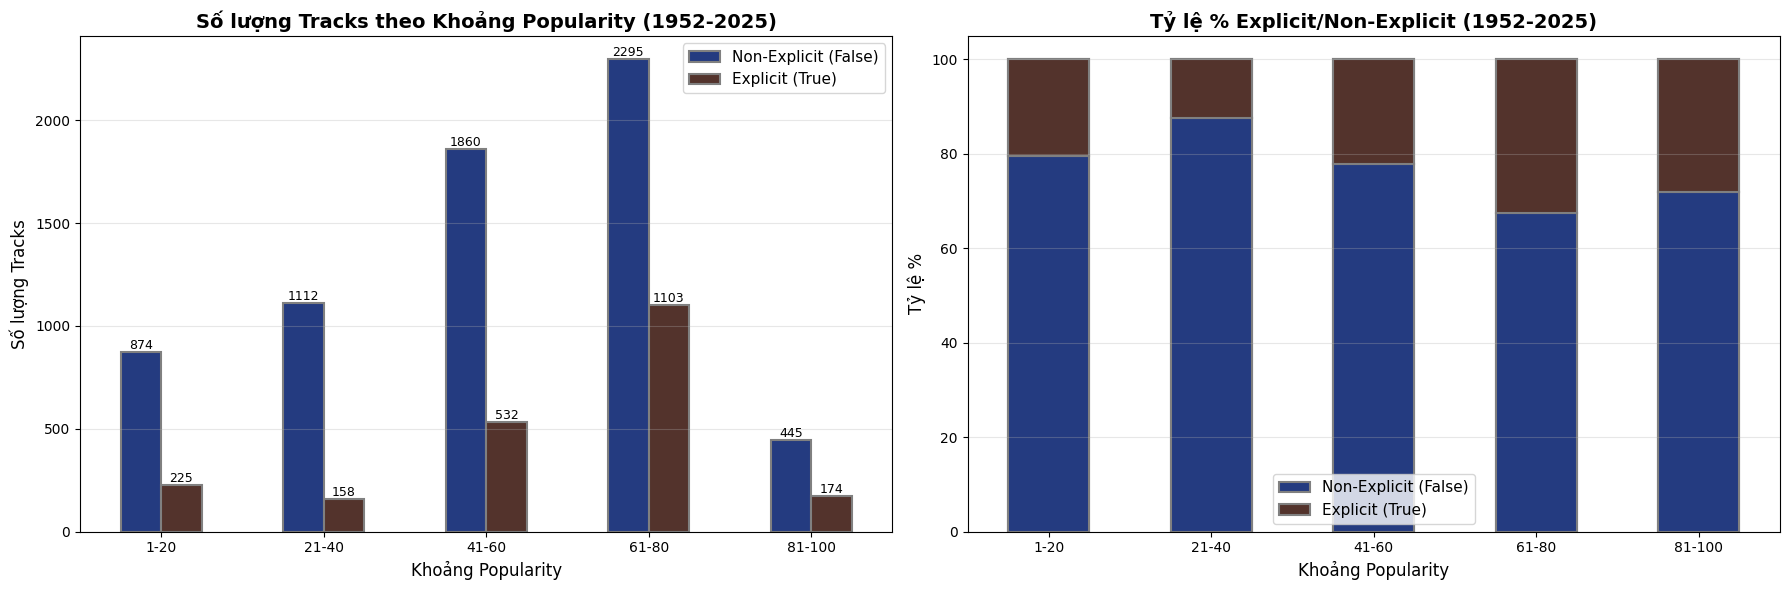

In [53]:
# Phân bố Explicit/Non-Explicit theo khoảng Popularity
# Tạo các khoảng popularity
bins = [0, 20, 40, 60, 80, 100]
labels = ['1-20', '21-40', '41-60', '61-80', '81-100']
df['popularity_range'] = pd.cut(df['track_popularity'], bins=bins, labels=labels, include_lowest=True)

# Lấy thông tin năm
df_temp = df.copy()
df_temp['release_year'] = pd.to_datetime(df_temp['album_release_date'], format='mixed', errors='coerce').dt.year
min_year = int(df_temp['release_year'].min())
max_year = int(df_temp['release_year'].max())
year_range = max_year - min_year + 1

# Đếm số lượng explicit và non-explicit trong mỗi khoảng
popularity_explicit = df.groupby(['popularity_range', 'explicit']).size().unstack(fill_value=0)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# 1. Stacked Bar Chart
popularity_explicit.plot(kind='bar', stacked=False, ax=axes[0], color=["#243B80", "#53332C"], edgecolor='gray', linewidth=1.5)
axes[0].set_title(f'Số lượng Tracks theo Khoảng Popularity ({min_year}-{max_year})', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Khoảng Popularity', fontsize=12)
axes[0].set_ylabel('Số lượng Tracks', fontsize=12)
axes[0].legend(['Non-Explicit (False)', 'Explicit (True)'], fontsize=11)
axes[0].tick_params(axis='x', rotation=0)
axes[0].grid(True, alpha=0.3, axis='y')

# Thêm giá trị lên các cột
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%d', fontsize=9)

# 2. Percentage Stacked Bar Chart
popularity_explicit_pct = popularity_explicit.div(popularity_explicit.sum(axis=1), axis=0) * 100
popularity_explicit_pct.plot(kind='bar', stacked=True, ax=axes[1],
                              color=['#243B80', '#53332C'],
                                edgecolor='gray', linewidth=1.5)
popularity_explicit_pct.plot(kind='bar', stacked=True, ax=axes[1], color=['#243B80', '#53332C'], edgecolor='gray', linewidth=1.5)
axes[1].set_title(f'Tỷ lệ % Explicit/Non-Explicit ({min_year}-{max_year})', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Khoảng Popularity', fontsize=12)
axes[1].set_ylabel('Tỷ lệ %', fontsize=12)
axes[1].legend(['Non-Explicit (False)', 'Explicit (True)'], fontsize=11)
axes[1].tick_params(axis='x', rotation=0)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

C:\Users\LIANLI\AppData\Local\Temp\ipykernel_26968\4198721659.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = axes[0, 0].boxplot([df[df['explicit']==False]['track_popularity'].dropna(),
C:\Users\LIANLI\AppData\Local\Temp\ipykernel_26968\4198721659.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = axes[0, 1].boxplot([df[df['explicit']==False]['artist_popularity'].dropna(),


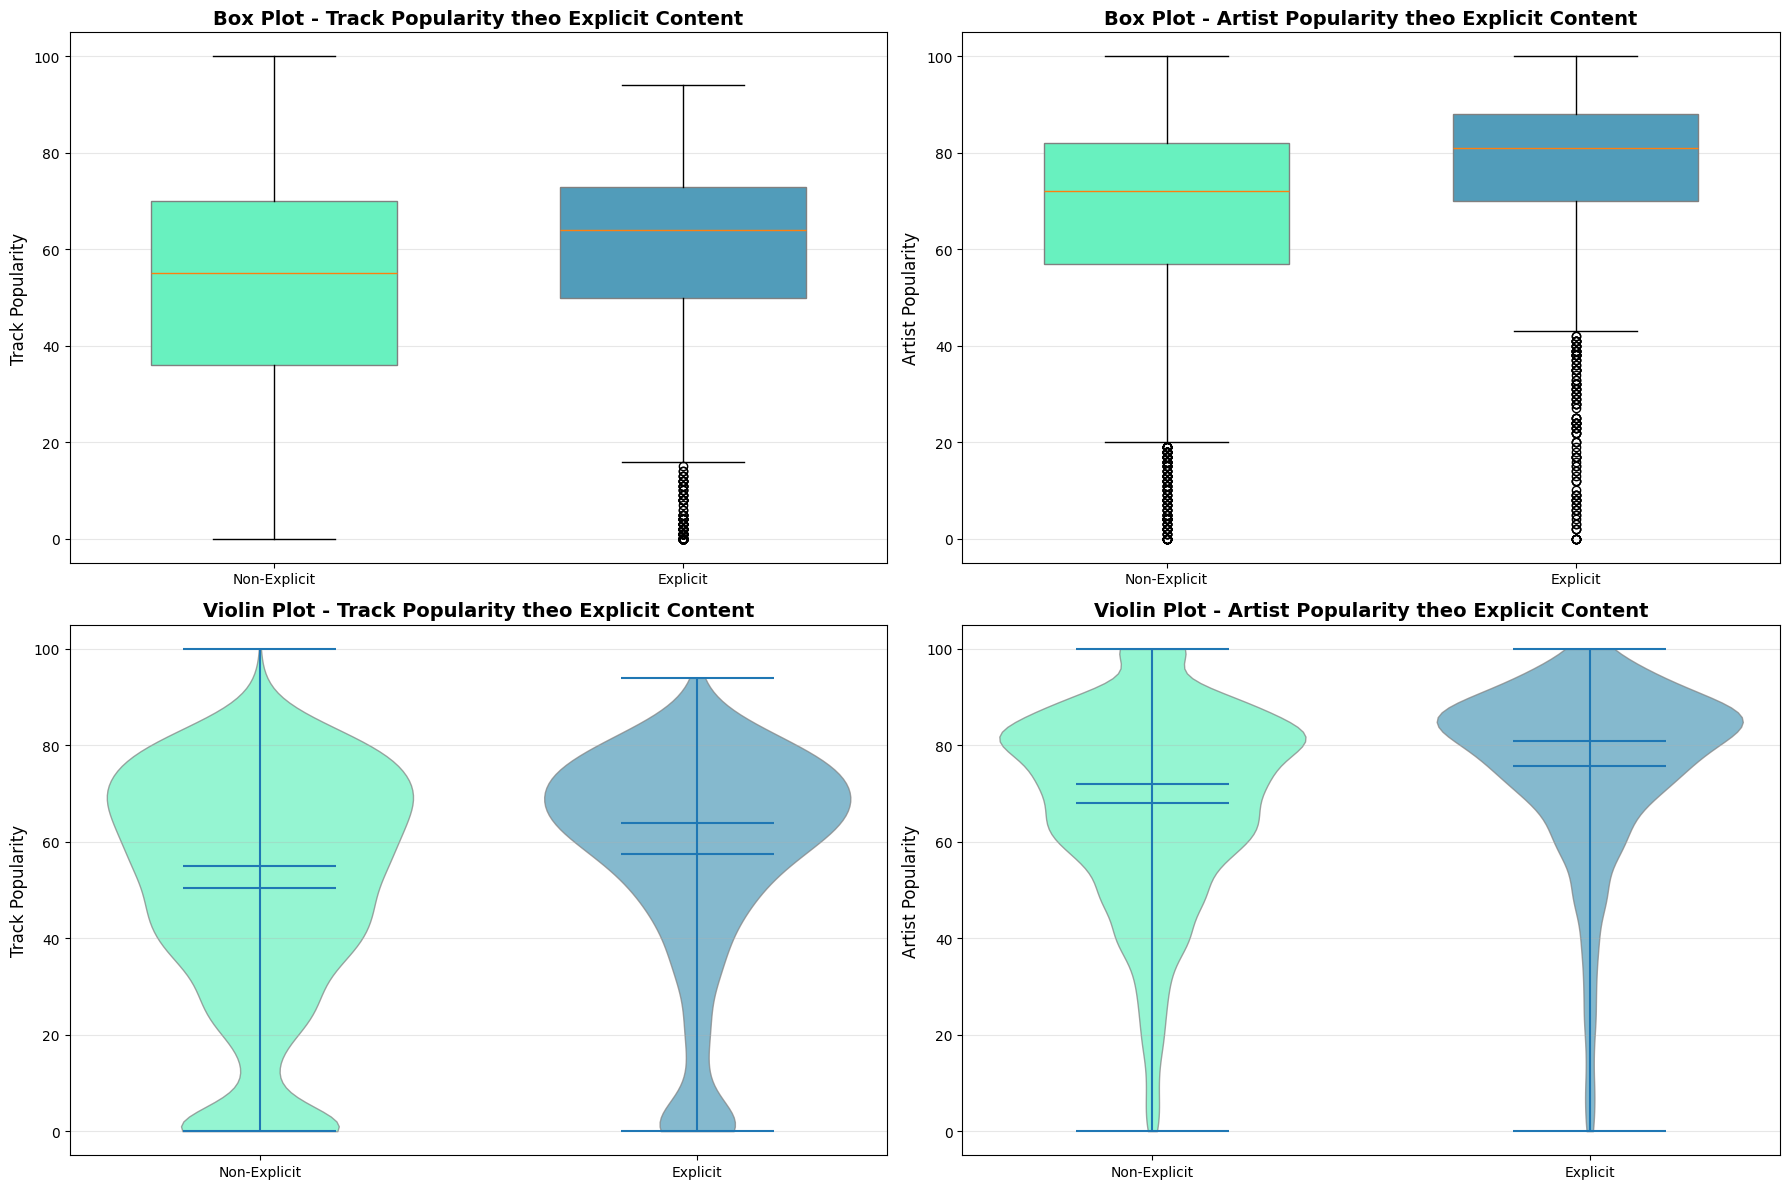

In [54]:
# Box Plot và Violin Plot - So sánh Popularity giữa Explicit và Non-Explicit
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Màu sắc pastel nhẹ nhàng
colors_palette = {False: "#68F1BF", True: "#519CBA"}  # False=Non-Explicit (xanh), True=Explicit (đỏ)

# 1. Box Plot - Track Popularity
axes[0, 0].set_title('Box Plot - Track Popularity theo Explicit Content', fontsize=14, fontweight='bold')
bp1 = axes[0, 0].boxplot([df[df['explicit']==False]['track_popularity'].dropna(),
                            df[df['explicit']==True]['track_popularity'].dropna()],
                          labels=['Non-Explicit', 'Explicit'],
                          patch_artist=True,
                          widths=0.6)
for patch, color in zip(bp1['boxes'], [colors_palette[False], colors_palette[True]]):
    patch.set_facecolor(color)
    patch.set_edgecolor('gray')
axes[0, 0].set_ylabel('Track Popularity', fontsize=12)
axes[0, 0].grid(True, alpha=0.3, axis='y')

# 2. Box Plot - Artist Popularity
axes[0, 1].set_title('Box Plot - Artist Popularity theo Explicit Content', fontsize=14, fontweight='bold')
bp2 = axes[0, 1].boxplot([df[df['explicit']==False]['artist_popularity'].dropna(),
                            df[df['explicit']==True]['artist_popularity'].dropna()],
                          labels=['Non-Explicit', 'Explicit'],
                          patch_artist=True,
                          widths=0.6)
for patch, color in zip(bp2['boxes'], [colors_palette[False], colors_palette[True]]):
    patch.set_facecolor(color)
    patch.set_edgecolor('gray')
axes[0, 1].set_ylabel('Artist Popularity', fontsize=12)
axes[0, 1].grid(True, alpha=0.3, axis='y')

# 3. Violin Plot - Track Popularity
axes[1, 0].set_title('Violin Plot - Track Popularity theo Explicit Content', fontsize=14, fontweight='bold')
parts1 = axes[1, 0].violinplot([df[df['explicit']==False]['track_popularity'].dropna(),
                                 df[df['explicit']==True]['track_popularity'].dropna()],
                                positions=[1, 2],
                                showmeans=True,
                                showmedians=True,
                                widths=0.7)
for i, pc in enumerate(parts1['bodies']):
    pc.set_facecolor(colors_palette[i==1])
    pc.set_alpha(0.7)
    pc.set_edgecolor('gray')
axes[1, 0].set_xticks([1, 2])
axes[1, 0].set_xticklabels(['Non-Explicit', 'Explicit'])
axes[1, 0].set_ylabel('Track Popularity', fontsize=12)
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 4. Violin Plot - Artist Popularity
axes[1, 1].set_title('Violin Plot - Artist Popularity theo Explicit Content', fontsize=14, fontweight='bold')
parts2 = axes[1, 1].violinplot([df[df['explicit']==False]['artist_popularity'].dropna(),
                                 df[df['explicit']==True]['artist_popularity'].dropna()],
                                positions=[1, 2],
                                showmeans=True,
                                showmedians=True,
                                widths=0.7)
for i, pc in enumerate(parts2['bodies']):
    pc.set_facecolor(colors_palette[i==1])
    pc.set_alpha(0.7)
    pc.set_edgecolor('gray')
axes[1, 1].set_xticks([1, 2])
axes[1, 1].set_xticklabels(['Non-Explicit', 'Explicit'])
axes[1, 1].set_ylabel('Artist Popularity', fontsize=12)
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

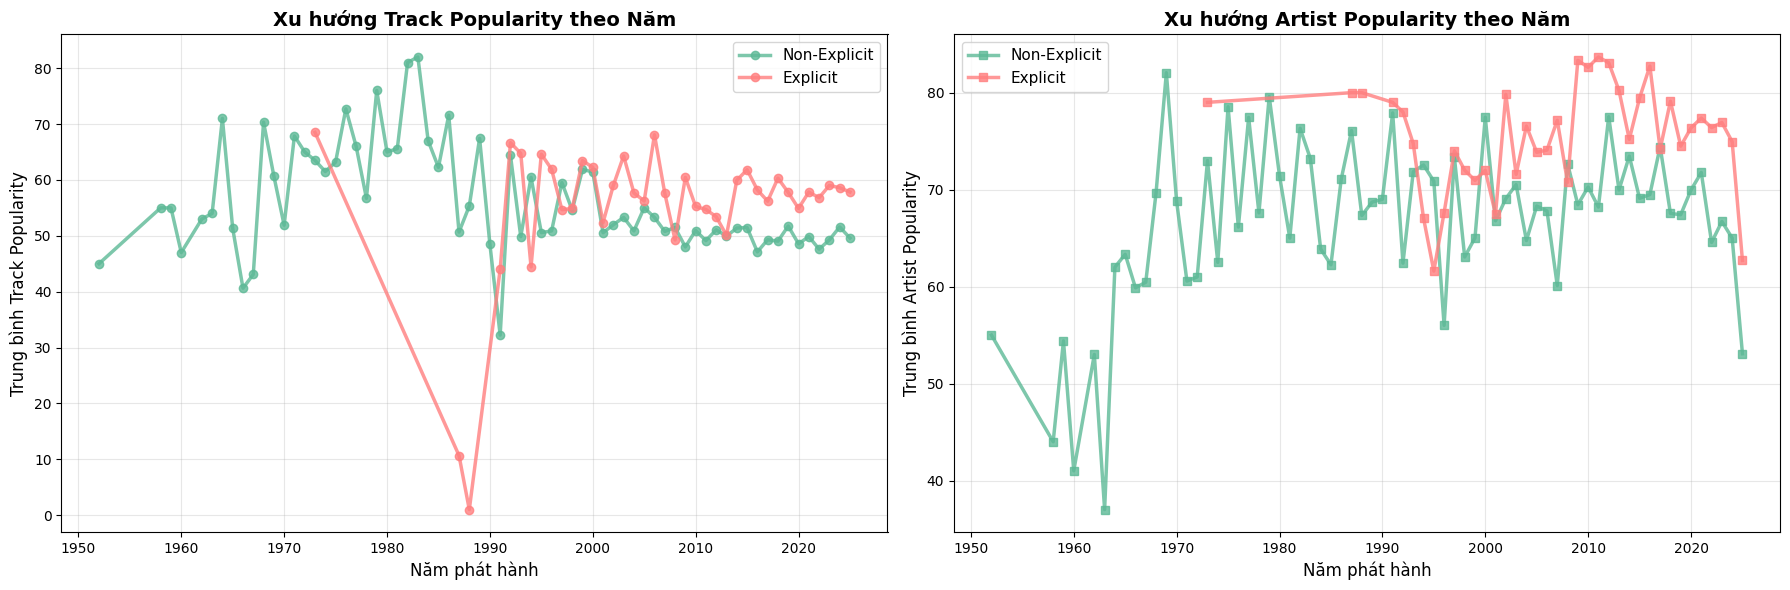

In [55]:
# Xu hướng Popularity theo Năm - Explicit vs Non-Explicit
# Tạo cột release_year
df['release_year'] = pd.to_datetime(df['album_release_date'], format='mixed', errors='coerce').dt.year

# Tính popularity trung bình theo năm cho explicit và non-explicit
yearly_track_pop = df.groupby(['release_year', 'explicit'])['track_popularity'].mean().reset_index()
yearly_artist_pop = df.groupby(['release_year', 'explicit'])['artist_popularity'].mean().reset_index()

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

colors_line = {False: '#5DB996', True: '#FF7F7F'}  # Non-Explicit (xanh đậm hơn), Explicit (đỏ đậm hơn)

# 1. Line Chart - Track Popularity theo Năm
for explicit_val in [False, True]:
    data = yearly_track_pop[yearly_track_pop['explicit'] == explicit_val]
    label = 'Explicit' if explicit_val else 'Non-Explicit'
    axes[0].plot(data['release_year'], data['track_popularity'], 
                 marker='o', label=label, linewidth=2.5, markersize=6,
                 color=colors_line[explicit_val], alpha=0.8)

axes[0].set_title('Xu hướng Track Popularity theo Năm', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Năm phát hành', fontsize=12)
axes[0].set_ylabel('Trung bình Track Popularity', fontsize=12)
axes[0].legend(fontsize=11, loc='best')
axes[0].grid(True, alpha=0.3)

# 2. Line Chart - Artist Popularity theo Năm
for explicit_val in [False, True]:
    data = yearly_artist_pop[yearly_artist_pop['explicit'] == explicit_val]
    label = 'Explicit' if explicit_val else 'Non-Explicit'
    axes[1].plot(data['release_year'], data['artist_popularity'], 
                 marker='s', label=label, linewidth=2.5, markersize=6,
                 color=colors_line[explicit_val], alpha=0.8)

axes[1].set_title('Xu hướng Artist Popularity theo Năm', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Năm phát hành', fontsize=12)
axes[1].set_ylabel('Trung bình Artist Popularity', fontsize=12)
axes[1].legend(fontsize=11, loc='best')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

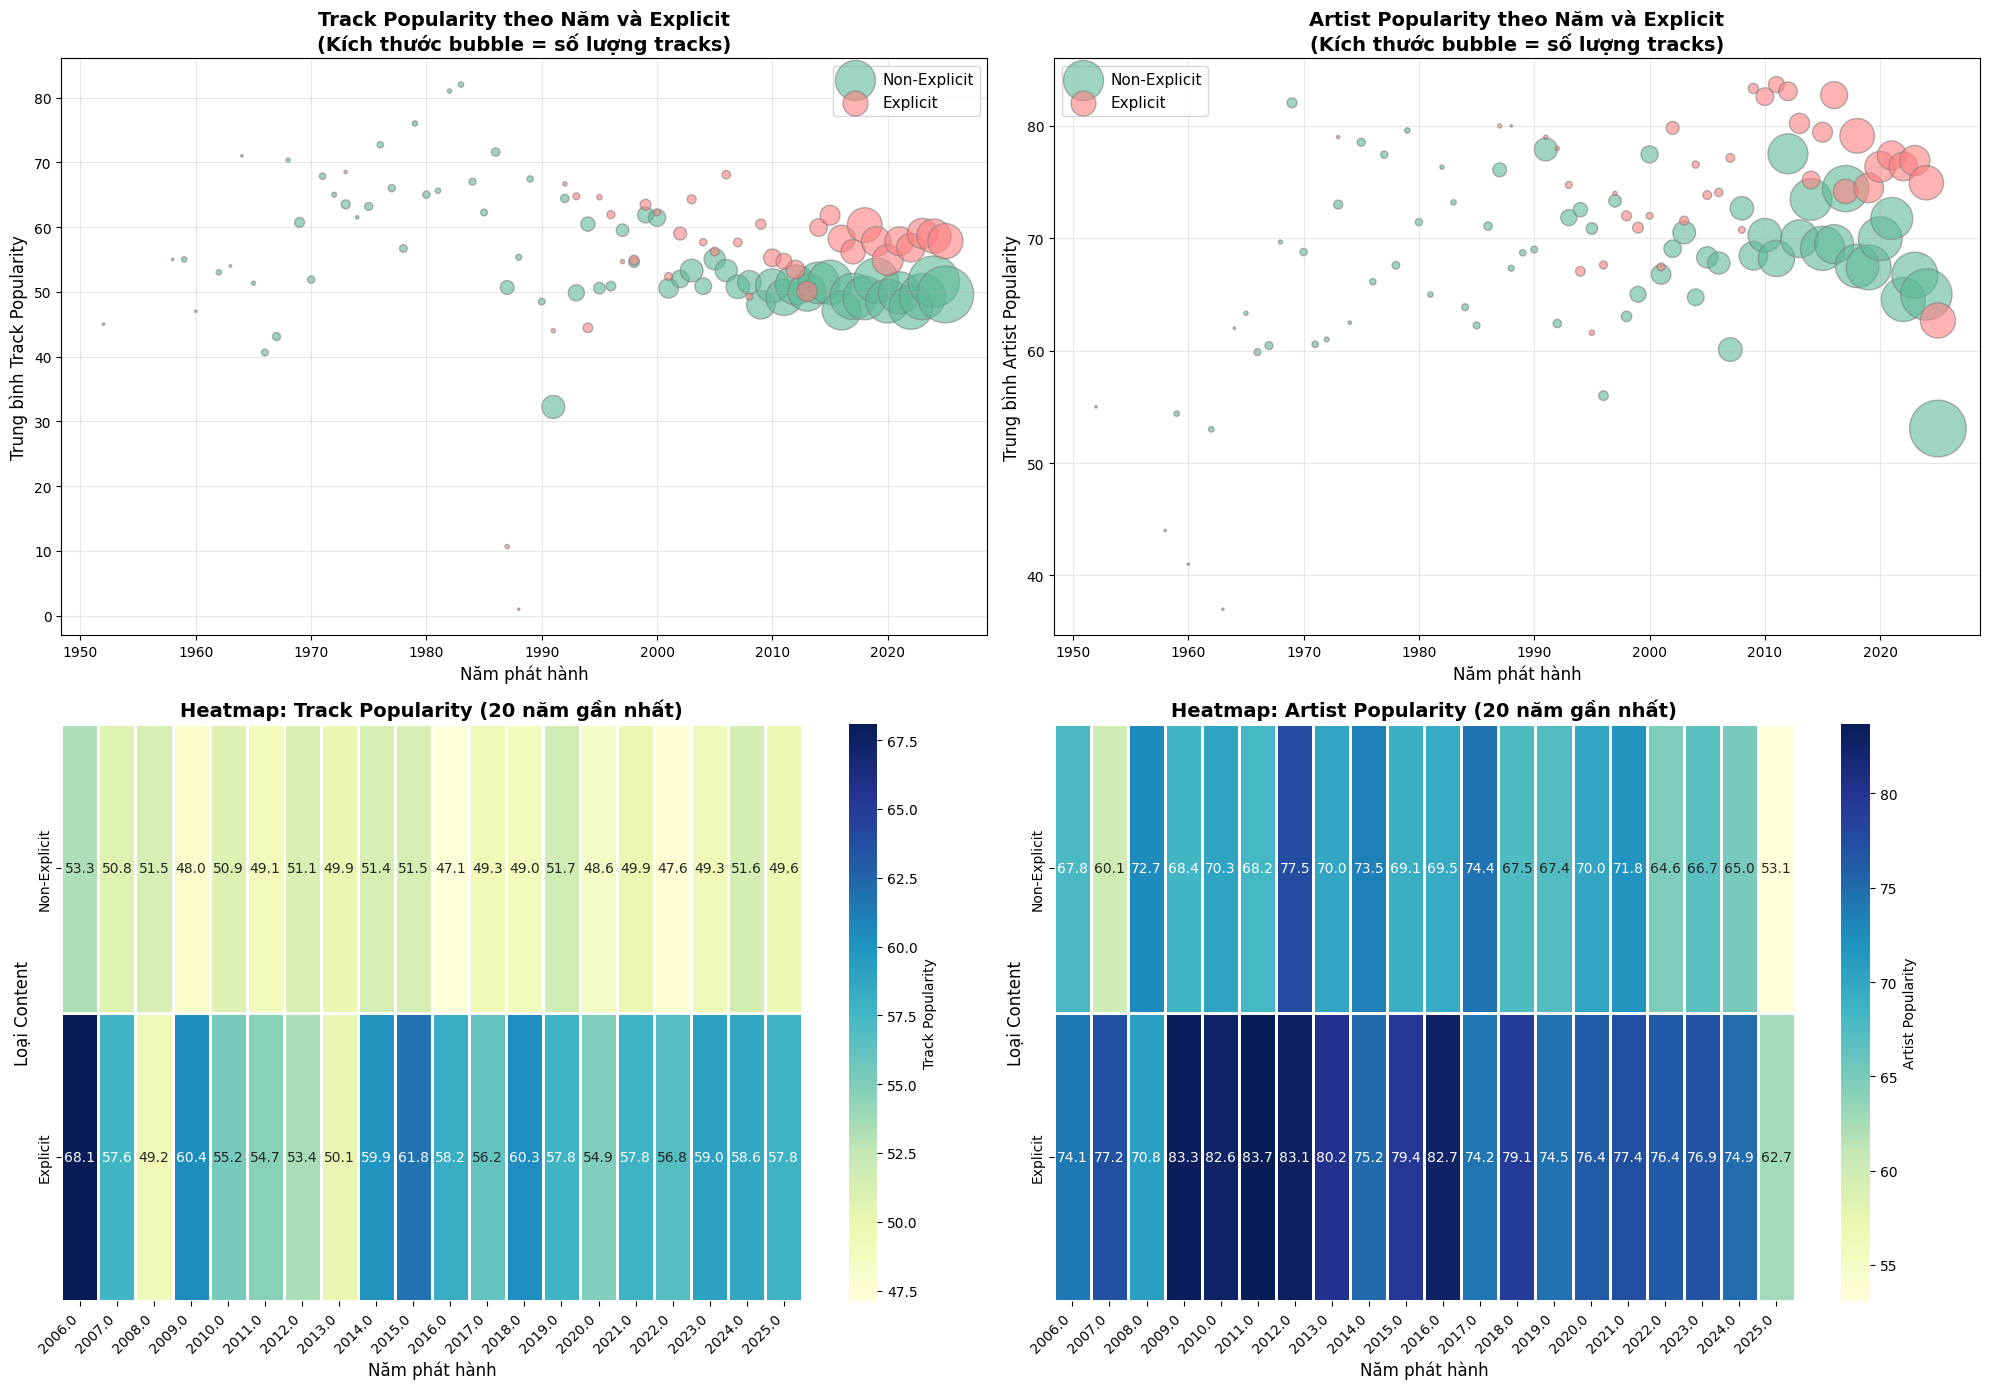

In [56]:
# Visualization kết hợp: Năm, Popularity và Explicit

# Tính popularity trung bình và số lượng tracks theo năm và explicit
yearly_stats = df.groupby(['release_year', 'explicit']).agg({
    'track_popularity': 'mean',
    'artist_popularity': 'mean',
    'track_id': 'count'  # Đếm số lượng tracks
}).reset_index()
yearly_stats.columns = ['release_year', 'explicit', 'track_pop_mean', 'artist_pop_mean', 'track_count']

# Visualize
fig, axes = plt.subplots(2, 2, figsize=(20, 14))

colors = {False: '#5DB996', True: '#FF7F7F'}  # Non-Explicit (xanh), Explicit (đỏ)

# 1. Scatter Plot - Track Popularity theo Năm (Size = số lượng tracks)
for explicit_val in [False, True]:
    data = yearly_stats[yearly_stats['explicit'] == explicit_val]
    label = 'Explicit' if explicit_val else 'Non-Explicit'
    axes[0, 0].scatter(data['release_year'], data['track_pop_mean'], 
                       s=data['track_count']*3,  # Size tỉ lệ với số tracks
                       alpha=0.6, 
                       color=colors[explicit_val],
                       label=label,
                       edgecolor='gray',
                       linewidth=1)

axes[0, 0].set_title('Track Popularity theo Năm và Explicit\n(Kích thước bubble = số lượng tracks)', 
                     fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Năm phát hành', fontsize=12)
axes[0, 0].set_ylabel('Trung bình Track Popularity', fontsize=12)
axes[0, 0].legend(fontsize=11, loc='best')
axes[0, 0].grid(True, alpha=0.3)

# 2. Scatter Plot - Artist Popularity theo Năm
for explicit_val in [False, True]:
    data = yearly_stats[yearly_stats['explicit'] == explicit_val]
    label = 'Explicit' if explicit_val else 'Non-Explicit'
    axes[0, 1].scatter(data['release_year'], data['artist_pop_mean'], 
                       s=data['track_count']*3,
                       alpha=0.6, 
                       color=colors[explicit_val],
                       label=label,
                       edgecolor='gray',
                       linewidth=1)

axes[0, 1].set_title('Artist Popularity theo Năm và Explicit\n(Kích thước bubble = số lượng tracks)', 
                     fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Năm phát hành', fontsize=12)
axes[0, 1].set_ylabel('Trung bình Artist Popularity', fontsize=12)
axes[0, 1].legend(fontsize=11, loc='best')
axes[0, 1].grid(True, alpha=0.3)

# 3. Heatmap - Track Popularity theo Năm x Explicit
pivot_track = yearly_stats.pivot(index='release_year', columns='explicit', values='track_pop_mean')
pivot_track.columns = ['Non-Explicit', 'Explicit']

# Chỉ lấy 20 năm gần nhất để dễ nhìn
recent_years = sorted(pivot_track.index)[-20:]
pivot_track_recent = pivot_track.loc[recent_years]

sns.heatmap(pivot_track_recent.T, 
            annot=True, 
            fmt='.1f',
            cmap='YlGnBu',
            cbar_kws={'label': 'Track Popularity'},
            linewidths=1,
            linecolor='white',
            ax=axes[1, 0])
axes[1, 0].set_title(f'Heatmap: Track Popularity (20 năm gần nhất)', 
                     fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Năm phát hành', fontsize=12)
axes[1, 0].set_ylabel('Loại Content', fontsize=12)
axes[1, 0].set_xticklabels(axes[1, 0].get_xticklabels(), rotation=45, ha='right')

# 4. Heatmap - Artist Popularity theo Năm x Explicit
pivot_artist = yearly_stats.pivot(index='release_year', columns='explicit', values='artist_pop_mean')
pivot_artist.columns = ['Non-Explicit', 'Explicit']
pivot_artist_recent = pivot_artist.loc[recent_years]

sns.heatmap(pivot_artist_recent.T, 
            annot=True, 
            fmt='.1f',
            cmap='YlGnBu',
            cbar_kws={'label': 'Artist Popularity'},
            linewidths=1,
            linecolor='white',
            ax=axes[1, 1])
axes[1, 1].set_title(f'Heatmap: Artist Popularity (20 năm gần nhất)', 
                     fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Năm phát hành', fontsize=12)
axes[1, 1].set_ylabel('Loại Content', fontsize=12)
axes[1, 1].set_xticklabels(axes[1, 1].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()